In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Train-Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor

# Validation & Tuning
from sklearn.model_selection import cross_val_score, GridSearchCV

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, r2_score

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load California Housing Dataset
housing = fetch_california_housing(as_frame=True)

# Features
X = housing.data

# Target
y = housing.target

print("Dataset Shape:", X.shape)
print("\nFirst 5 Rows:")
display(X.head())

Dataset Shape: (20640, 8)

First 5 Rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
# Create scaler object
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

print("Feature Scaling Completed")

Feature Scaling Completed


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 16512
Testing Samples  : 4128


In [5]:
# Create model
lr = LinearRegression()

# Train
lr.fit(X_train, y_train)

# Predict
lr_pred = lr.predict(X_test)

# Metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results")
print("RMSE :", round(lr_rmse,4))
print("R²   :", round(lr_r2,4))

Linear Regression Results
RMSE : 0.7456
R²   : 0.5758


In [6]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression Results")
print("RMSE :", round(ridge_rmse,4))
print("R²   :", round(ridge_r2,4))

Ridge Regression Results
RMSE : 0.7456
R²   : 0.5758


In [7]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

# Predictions
train_pred = tree.predict(X_train)
test_pred = tree.predict(X_test)

# Train RMSE
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

# Test RMSE
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Decision Tree Performance")

print("Train RMSE :", round(train_rmse,4))
print("Test RMSE  :", round(test_rmse,4))

Decision Tree Performance
Train RMSE : 0.0
Test RMSE  : 0.703


In [8]:
gap = test_rmse - train_rmse

print("Difference Between Train and Test RMSE:", round(gap,4))

if gap > 0.5:
    print("Model is Overfitting")
else:
    print("Model is Generalizing Well")

Difference Between Train and Test RMSE: 0.703
Model is Overfitting


In [9]:
cv_scores = cross_val_score(
    tree,
    X_scaled,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores.mean()

print("Cross Validation RMSE Scores:")
print(-cv_scores)

print("\nAverage CV RMSE:", round(cv_rmse,4))

Cross Validation RMSE Scores:
[0.88767617 0.82781619 0.89845112 0.94507041 0.91950207]

Average CV RMSE: 0.8957


In [10]:
param_grid = {
    'max_depth':[3,5,7,10,15],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [11]:
best_tree = grid.best_estimator_

print(best_tree)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=4, random_state=42)


In [12]:
best_pred = best_tree.predict(X_test)

tuned_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
tuned_r2 = r2_score(y_test, best_pred)

print("Tuned Decision Tree Results")

print("RMSE :", round(tuned_rmse,4))
print("R²   :", round(tuned_r2,4))

Tuned Decision Tree Results
RMSE : 0.6389
R²   : 0.6885


In [13]:
tuned_cv = cross_val_score(
    best_tree,
    X_scaled,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

tuned_cv_rmse = -tuned_cv.mean()

print("Cross Validated RMSE:")
print(round(tuned_cv_rmse,4))

Cross Validated RMSE:
0.7687


In [14]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Ridge Regression',
        'Tuned Decision Tree'
    ],
    'RMSE':[
        lr_rmse,
        ridge_rmse,
        tuned_rmse
    ],
    'R2 Score':[
        lr_r2,
        ridge_r2,
        tuned_r2
    ]
})

results = results.sort_values(
    by='R2 Score',
    ascending=False
)

results

,Model,RMSE,R2 Score
2,Tuned Decision Tree,0.638936,0.688464
1,Ridge Regression,0.745554,0.575819
0,Linear Regression,0.745581,0.575788


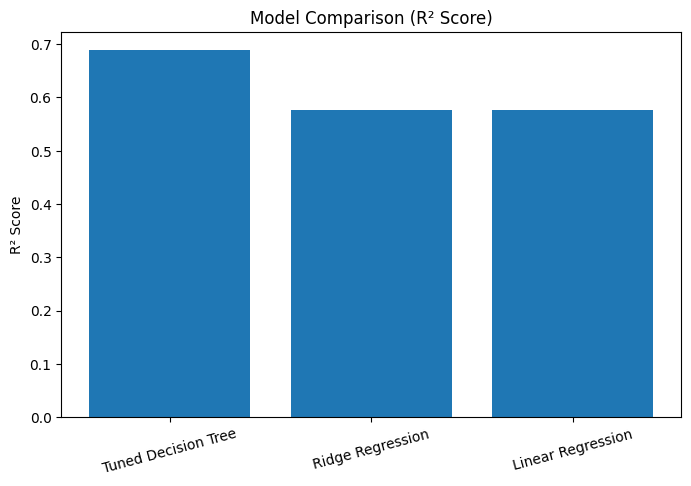

In [15]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['R2 Score'])

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.xticks(rotation=15)

plt.show()

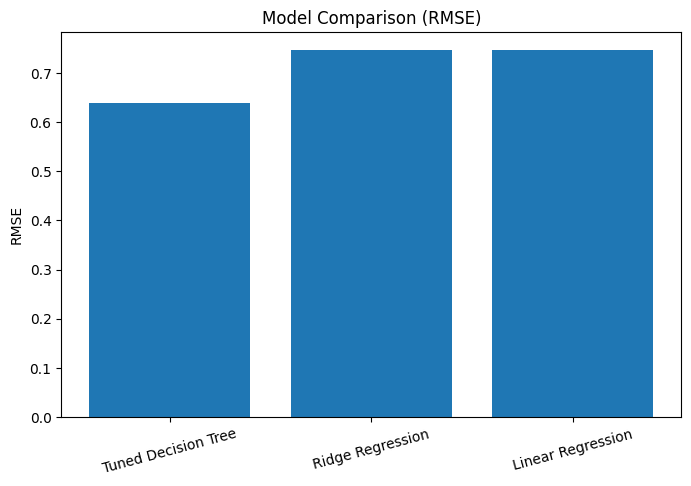

In [16]:
plt.figure(figsize=(8,5))

plt.bar(results['Model'], results['RMSE'])

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.xticks(rotation=15)

plt.show()

In [17]:
best_model = results.iloc[0]

print("Best Model Selected:")
print(best_model)

Best Model Selected:
Model       Tuned Decision Tree
RMSE                   0.638936
R2 Score               0.688464
Name: 2, dtype: object
